In [1]:
import torch
from torch import nn
from tqdm import tqdm
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2024-12-05 09:01:51.518260: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-05 09:01:51.523295: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-05 09:01:51.539940: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1733389311.567701   12813 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1733389311.575919   12813 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2) 

class TextDataset(Dataset):
    def __init__(self, texts, targets):
        self.texts = texts
        self.targets = targets

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text_tensor = self.texts[idx].clone().detach().to(device)
        
        target_tensor = torch.tensor(self.targets[idx], dtype=torch.float).to(device) 
        
        return text_tensor, target_tensor

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [4]:
import pandas as pd

df = pd.read_csv('amazon_rev/test.csv', engine='python', on_bad_lines='skip')
df = df.dropna()

In [5]:
import re

df['2'] = df['2'].apply(lambda x: [1, 0] if x == 1 else [0, 1]) 

texts = df[df.columns[-1]].tolist()
targets = df['2'].tolist()

positive_samples = df[df['2'].apply(lambda x: x == [1, 0])].sample(n=10000, random_state=42)
negative_samples = df[df['2'].apply(lambda x: x == [0, 1])].sample(n=10000, random_state=42)

combined_samples = pd.concat([positive_samples, negative_samples])

combined_samples = combined_samples.sample(frac=1, random_state=42).reset_index(drop=True)

texts = combined_samples[combined_samples.columns[-1]].tolist()
targets = combined_samples['2'].tolist()

encodings = tokenizer(
    texts,
    truncation=True,
    padding=True,
    max_length=512,
    return_tensors='pt'
)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(encodings['input_ids'], targets, test_size=0.2, random_state=42)

train_dataset = TextDataset(X_train, y_train)
test_dataset = TextDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

from torch.optim.lr_scheduler import CosineAnnealingLR

num_epochs = 100

model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.001)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
criterion = nn.BCEWithLogitsLoss()

In [7]:
def train(model, train_loader, optimizer, criterion, device, num_epochs=100):
    model.train()  
    for epoch in range(num_epochs):  
        total_loss = 0
        all_predictions = []
        all_targets = []
        
        for batch in tqdm(train_loader):
            input_ids, targets = batch
            attention_mask = (input_ids != 0).type(torch.int)
            
            input_ids = input_ids.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            
            logits = outputs.logits
            
            probabilities = torch.sigmoid(logits)  
            
            loss = criterion(logits, targets) 
            total_loss += loss.item()
            
            all_predictions.append(probabilities.detach().cpu().numpy())
            all_targets.append(targets.detach().cpu().numpy())

            loss.backward()
            optimizer.step()

        all_predictions = np.concatenate(all_predictions)
        all_targets = np.concatenate(all_targets)

        accuracy_train = accuracy_score(all_targets, (all_predictions > 0.5).astype(float))
        f1_train = f1_score(all_targets, (all_predictions > 0.5).astype(float), average='macro')
        
        print(f'Train Loss: {total_loss:.4f}, Train Accuracy: {accuracy_train:.4f}, Train F1 Score: {f1_train:.4f}')
        
        return total_loss, accuracy_train, f1_train

In [8]:
def test(model, test_loader, criterion, device):
    model.eval()  
    total_loss = 0
    all_predictions = []
    all_targets = []

    with torch.no_grad():  
        for batch in tqdm(test_loader):
            input_ids, targets = batch
            attention_mask = (input_ids != 0).type(torch.int)
            
            input_ids = input_ids.to(device)
            targets = targets.to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            
            logits = outputs.logits
            
            probabilities = torch.sigmoid(logits)  
            
            loss = criterion(logits, targets) 
            total_loss += loss.item()

            all_predictions.append(probabilities.detach().cpu().numpy())
            all_targets.append(targets.detach().cpu().numpy())

    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)

    accuracy_test = accuracy_score(all_targets, (all_predictions > 0.5).astype(float))
    f1_test = f1_score(all_targets, (all_predictions > 0.5).astype(float), average='macro')
    
    print(f'Test Loss: {total_loss:.4f}, Test Accuracy: {accuracy_test:.4f}, Test F1 Score: {f1_test:.4f}')
    
    return total_loss, accuracy_test, f1_test

In [9]:
torch.cuda.empty_cache()

In [10]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

patience = 5  
min_delta = 0.01  
best_metric = float('inf')  
patience_counter = 0  

train_losses = []
test_losses = []
f1_train_h = []
f1_test_t = []
accuracy_test_h = []
accuracy_train_h = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}{'-'*130}")
    
    loss_train, accuracy_train, f1_train = train(model, train_loader, optimizer, criterion, device)
    loss_test, accuracy_test, f1_test = test(model, test_loader, criterion, device)
    
    
    train_losses.append(loss_train) 
    test_losses.append(loss_test)   
    
    accuracy_train_h.append(accuracy_train)
    accuracy_test_h.append(accuracy_test)
    
    f1_train_h.append(f1_train)
    f1_test_t.append(f1_test)
    
    scheduler.step()
    current_metric = accuracy_test
    
    if current_metric > best_metric - min_delta:
        best_metric = current_metric
        patience_counter = 0  
        torch.save(model.state_dict(), 'best_model.pth')
    elif epoch != 0:
        patience_counter += 1
        print(f"Улучшения не обнаружено. Счетчик терпения: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("Ранняя остановка")
        break

Epoch 1/100----------------------------------------------------------------------------------------------------------------------------------


100%|██████████| 500/500 [02:19<00:00,  3.59it/s]


Train Loss: 138.6287, Train Accuracy: 0.8804, Train F1 Score: 0.8865


100%|██████████| 125/125 [00:11<00:00, 11.10it/s]


Test Loss: 28.8073, Test Accuracy: 0.9137, Test F1 Score: 0.9142
Epoch 2/100----------------------------------------------------------------------------------------------------------------------------------


...

Test Loss: 43.3804, Test Accuracy: 0.9193, Test F1 Score: 0.9194
Улучшения не обнаружено. Счетчик терпения: 4/5
Epoch 6/100----------------------------------------------------------------------------------------------------------------------------------


100%|██████████| 500/500 [02:18<00:00,  3.61it/s]


Train Loss: 13.4938, Train Accuracy: 0.9917, Train F1 Score: 0.9919


100%|██████████| 125/125 [00:11<00:00, 11.13it/s]

Test Loss: 49.4408, Test Accuracy: 0.9130, Test F1 Score: 0.9135
Улучшения не обнаружено. Счетчик терпения: 5/5
Ранняя остановка


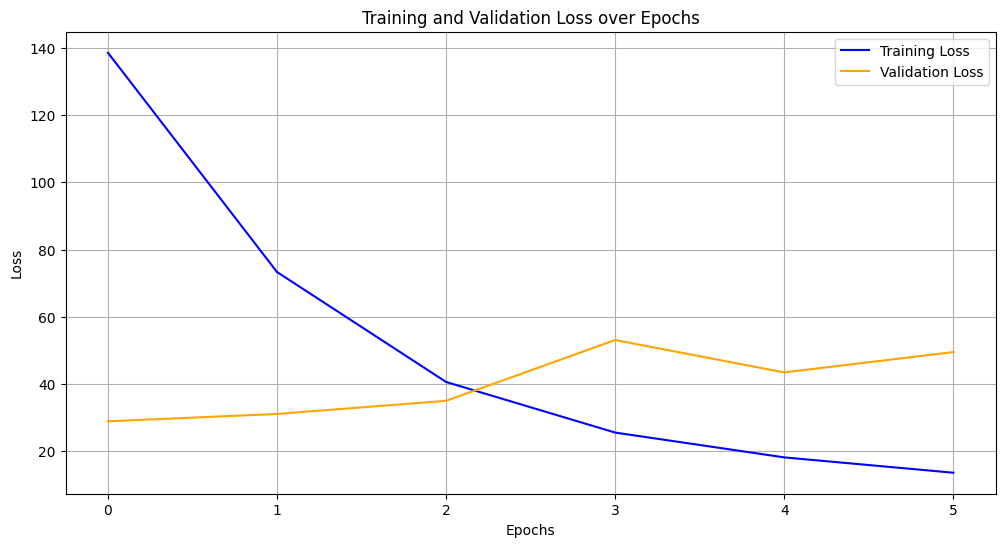

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(test_losses, label='Validation Loss', color='orange')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

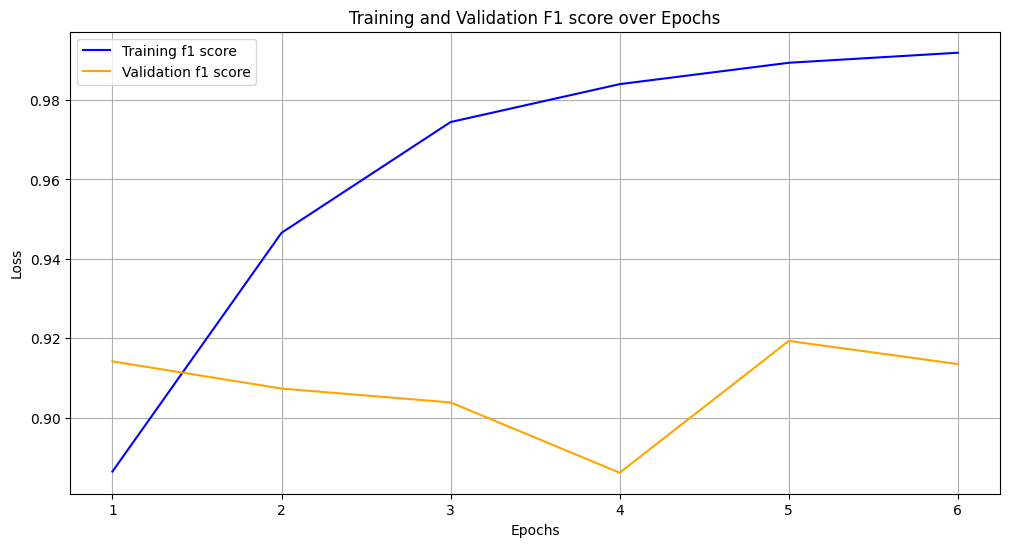

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(f1_train_h) + 1), f1_train_h, label='Training f1 score', color='blue')
plt.plot(range(1, len(f1_train_h) + 1), f1_test_t, label='Validation f1 score', color='orange')
plt.title('Training and Validation F1 score over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

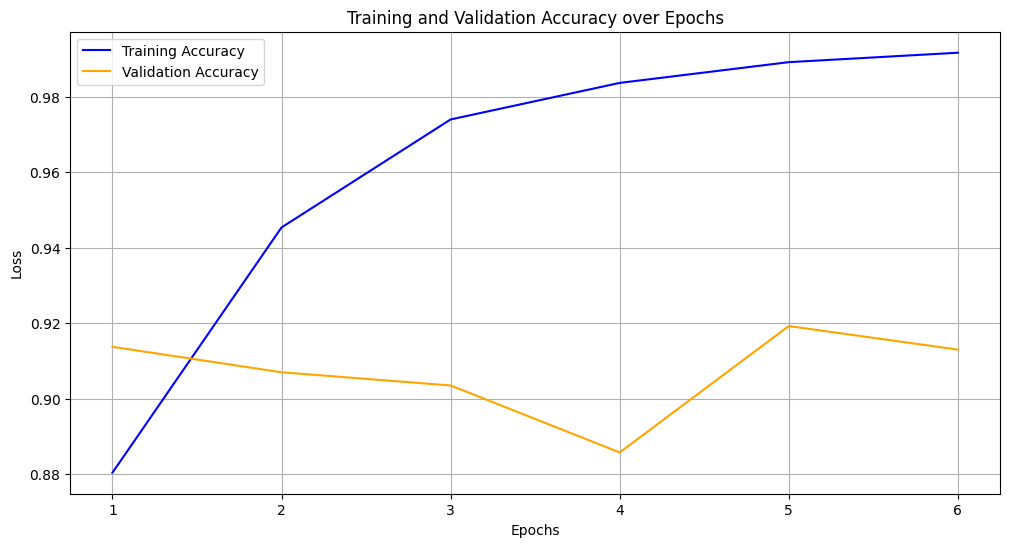

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(f1_train_h) + 1), accuracy_train_h, label='Training Accuracy', color='blue')
plt.plot(range(1, len(f1_train_h) + 1), accuracy_test_h, label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()